In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.stats as stats
from pathlib import Path

ROOT      = Path("..") 
PROCESSED = ROOT / "data" / "processed"

panel    = pd.read_parquet(PROCESSED / "panel.parquet")
estimate = pd.read_parquet(PROCESSED / "estimate_panel.parquet")

print(f"panel:    {panel.shape}")
print(f"estimate: {estimate.shape}")

panel:    (2455, 12)
estimate: (63744, 15)


In [2]:
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

plt.rcParams.update({
    "figure.dpi"      : 120,
    "axes.spines.top" : False,
    "axes.spines.right": False,
    "font.size"       : 11,
})

CATEGORY_ORDER = [
    "commodity_driven",
    "macro_rate_sensitive",
    "tech_cycle",
    "economically_cyclical",
    "regulatory_idiosyncratic",
    "defensive_baseline",
]

CAT_COLORS = {
    "commodity_driven"         : "#e07b39",
    "macro_rate_sensitive"     : "#4c7fb5",
    "tech_cycle"               : "#7cb86e",
    "economically_cyclical"    : "#c45c8a",
    "regulatory_idiosyncratic" : "#9b6bb5",
    "defensive_baseline"       : "#999999",
}

In [3]:
print("PANEL SUMMARY")
print()
print(f"Total rows        : {len(panel):,}")
print(f"Unique tickers    : {panel['act_symbol'].nunique()}")
print(f"Unique categories : {panel['category'].nunique()}")
print(f"Date range        : {panel['period_end_date'].min().date()} to {panel['period_end_date'].max().date()}")
print(f"Years covered     : {sorted(panel['year'].unique().tolist())}")

print()
print("ROWS BY CATEGORY")
print()
cat_counts = (
    panel.groupby("category")
         .size()
         .reindex(CATEGORY_ORDER)
         .rename("n_quarters")
)
print(cat_counts.to_string())

print()
print("ESTIMATE PANEL SUMMARY")
print()
print(f"Total rows        : {len(estimate):,}")
print(f"Unique tickers    : {estimate['act_symbol'].nunique()}")
print(f"Date range        : {estimate['date'].min().date()} to {estimate['date'].max().date()}")

PANEL SUMMARY

Total rows        : 2,455
Unique tickers    : 72
Unique categories : 6
Date range        : 2017-10-31 to 2026-05-31
Years covered     : [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]

ROWS BY CATEGORY

category
commodity_driven            406
macro_rate_sensitive        408
tech_cycle                  408
economically_cyclical       415
regulatory_idiosyncratic    408
defensive_baseline          410

ESTIMATE PANEL SUMMARY

Total rows        : 63,744
Unique tickers    : 72
Date range        : 2017-10-27 to 2026-06-14


In [4]:
quarters_per_ticker = (
    panel.groupby(["act_symbol", "category"])
         .size()
         .reset_index(name="n_quarters")
         .sort_values("n_quarters")
)

print(f"Min quarters per ticker : {quarters_per_ticker['n_quarters'].min()}")
print(f"Max quarters per ticker : {quarters_per_ticker['n_quarters'].max()}")
print(f"Mean                    : {quarters_per_ticker['n_quarters'].mean():.1f}")

thin = quarters_per_ticker[quarters_per_ticker["n_quarters"] < 30]
if len(thin) > 0:
    print(f"\nTickers with < 30 quarters ({len(thin)} found):")
    print(thin.to_string(index=False))
else:
    print("\nNo tickers with < 30 quarters.")

Min quarters per ticker : 32
Max quarters per ticker : 39
Mean                    : 34.1

No tickers with < 30 quarters.


In [5]:
panel_keys    = set(zip(panel["act_symbol"], panel["period_end_date"]))
estimate_keys = set(zip(estimate["act_symbol"], estimate["period_end_date"]))

in_panel_not_estimate = panel_keys - estimate_keys
in_estimate_not_panel = estimate_keys - panel_keys

print(f"Ticker-quarters in panel                  : {len(panel_keys):,}")
print(f"Ticker-quarters in estimate panel          : {len(estimate_keys):,}")
print(f"In panel but missing from estimate         : {len(in_panel_not_estimate)}")
print(f"In estimate but no actuals (future qtrs)   : {len(in_estimate_not_panel)}")

if in_panel_not_estimate:
    print("\nMissing estimate history for these quarters:")
    for sym, dt in sorted(in_panel_not_estimate):
        print(f"  {sym:6s}  {dt.date()}")

Ticker-quarters in panel                  : 2,455
Ticker-quarters in estimate panel          : 2,611
In panel but missing from estimate         : 7
In estimate but no actuals (future qtrs)   : 163

Missing estimate history for these quarters:
  DE      2020-12-31
  DE      2021-03-31
  DE      2021-06-30
  DE      2021-09-30
  LIN     2017-12-31
  LIN     2018-03-31
  LIN     2018-06-30


## Cross-panel integrity

7 ticker-quarters in `panel` have no estimate history:
- **DE (4 quarters):** fiscal year date alignment - DE's quarter ends don't match calendar months
- **LIN (3 quarters):** pre-merger quarters with no consensus snapshots

These 7 rows are retained in panel.parquet for F1/F2 analysis but will be excluded from F3 (revision path) when features.py merges the panels.

In [6]:
beat_stats = (
    panel.groupby("category")["beat"]
         .agg(["mean", "count"])
         .reindex(CATEGORY_ORDER)
         .rename(columns={"mean": "beat_rate", "count": "n"})
)
beat_stats["beat_rate_pct"] = beat_stats["beat_rate"] * 100

print(f"Overall beat rate: {panel['beat'].mean()*100:.1f}%")
print()
print(beat_stats[["beat_rate_pct", "n"]].to_string(float_format="{:.1f}".format))

Overall beat rate: 82.7%

                          beat_rate_pct    n
category                                    
commodity_driven                   76.6  406
macro_rate_sensitive               84.8  408
tech_cycle                         90.7  408
economically_cyclical              77.1  415
regulatory_idiosyncratic           89.0  408
defensive_baseline                 78.3  410


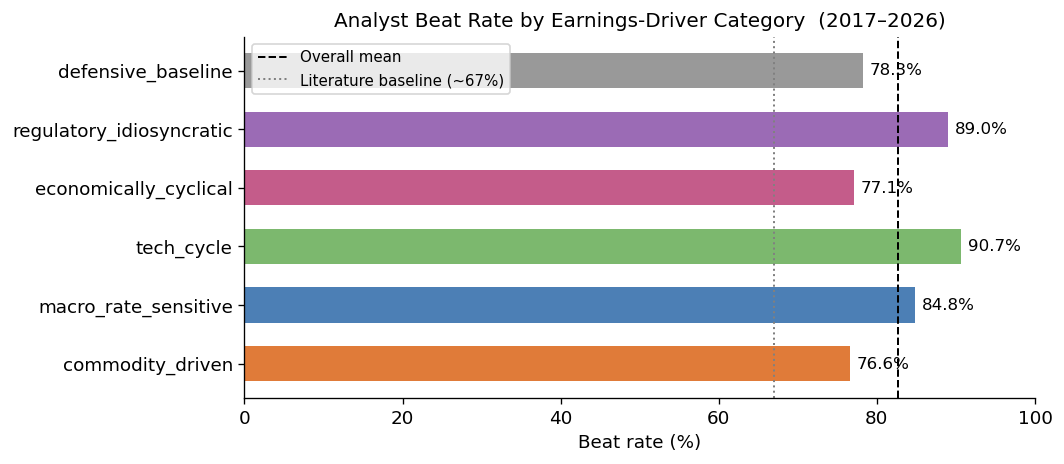

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = [CAT_COLORS[c] for c in CATEGORY_ORDER]
bars   = ax.barh(CATEGORY_ORDER, beat_stats["beat_rate_pct"], color=colors, height=0.6)

ax.axvline(panel["beat"].mean() * 100, color="black", linestyle="--", linewidth=1.2, label="Overall mean")
ax.axvline(67, color="grey", linestyle=":", linewidth=1.2, label="Literature baseline (~67%)")
ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=10)
ax.set_xlabel("Beat rate (%)")
ax.set_title("Analyst Beat Rate by Earnings-Driver Category  (2017–2026)", fontsize=12)
ax.set_xlim(0, 100)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../reports/figures/02_beat_rate_by_category.png", dpi=150)
plt.show()

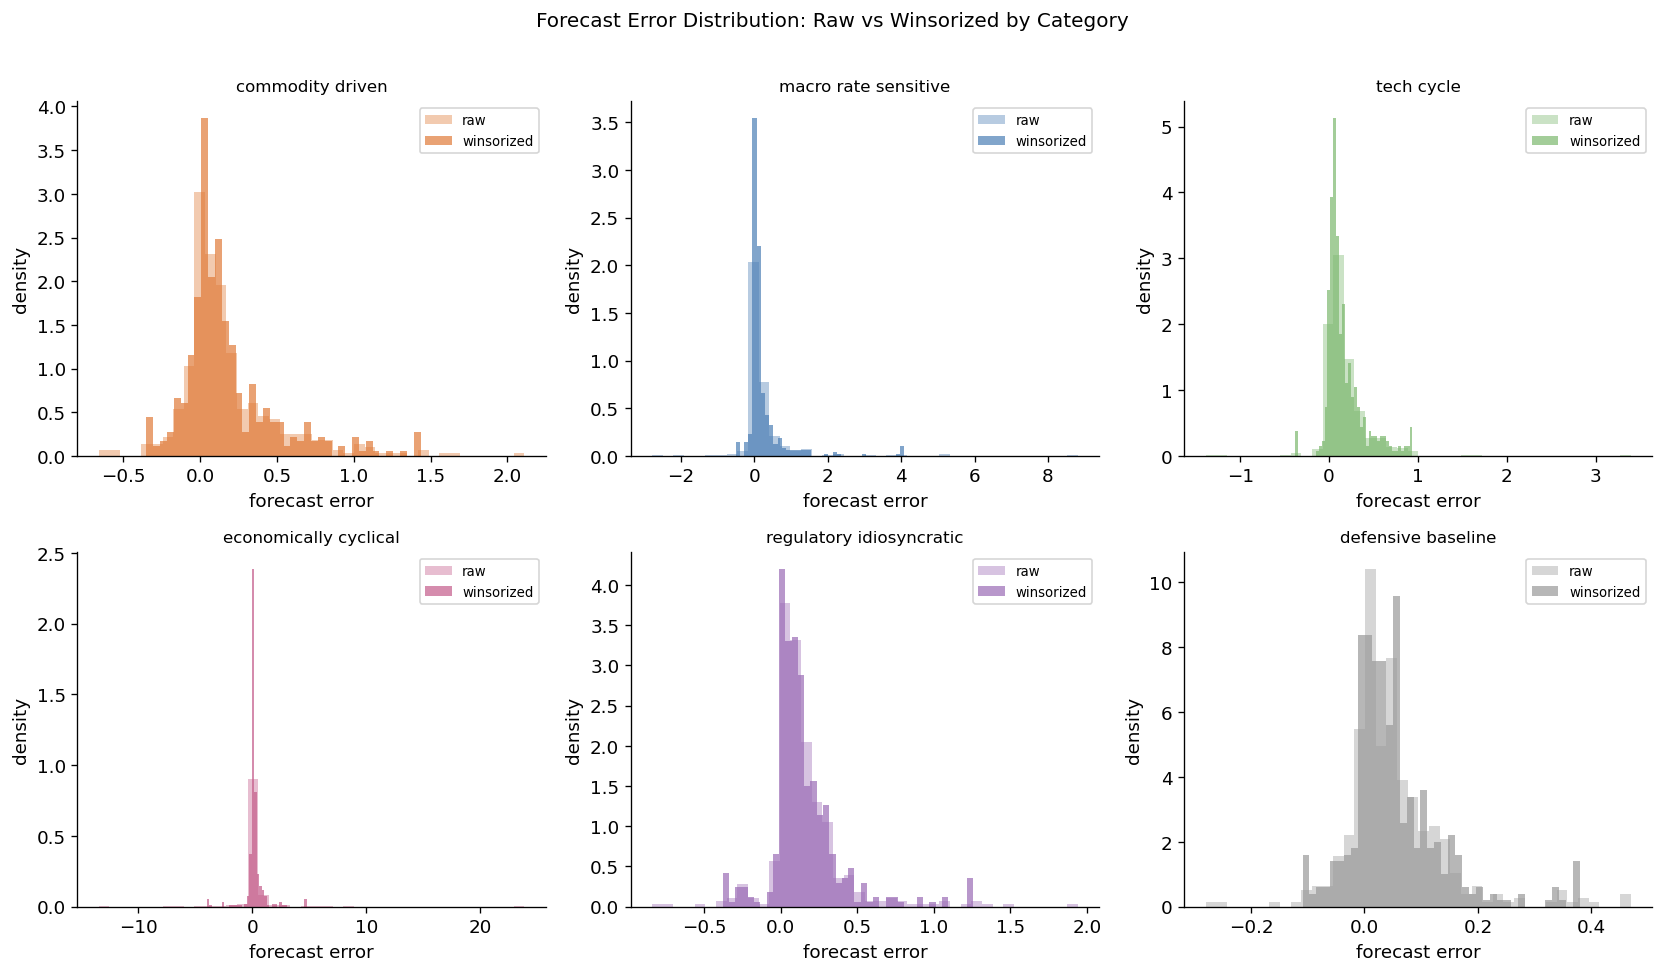

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=False)
axes = axes.flatten()

for i, cat in enumerate(CATEGORY_ORDER):
    ax   = axes[i]
    data = panel[panel["category"] == cat]

    ax.hist(data["forecast_error"], bins=40, alpha=0.4,
            color=CAT_COLORS[cat], label="raw", density=True)
    ax.hist(data["forecast_error_winsorized"], bins=40, alpha=0.7,
            color=CAT_COLORS[cat], label="winsorized", density=True)

    ax.set_title(cat.replace("_", " "), fontsize=10)
    ax.set_xlabel("forecast error")
    ax.set_ylabel("density")
    ax.legend(fontsize=8)

fig.suptitle("Forecast Error Distribution: Raw vs Winsorized by Category", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("../reports/figures/02_error_distribution_raw_vs_winsorized.png", dpi=150, bbox_inches="tight")
plt.show()

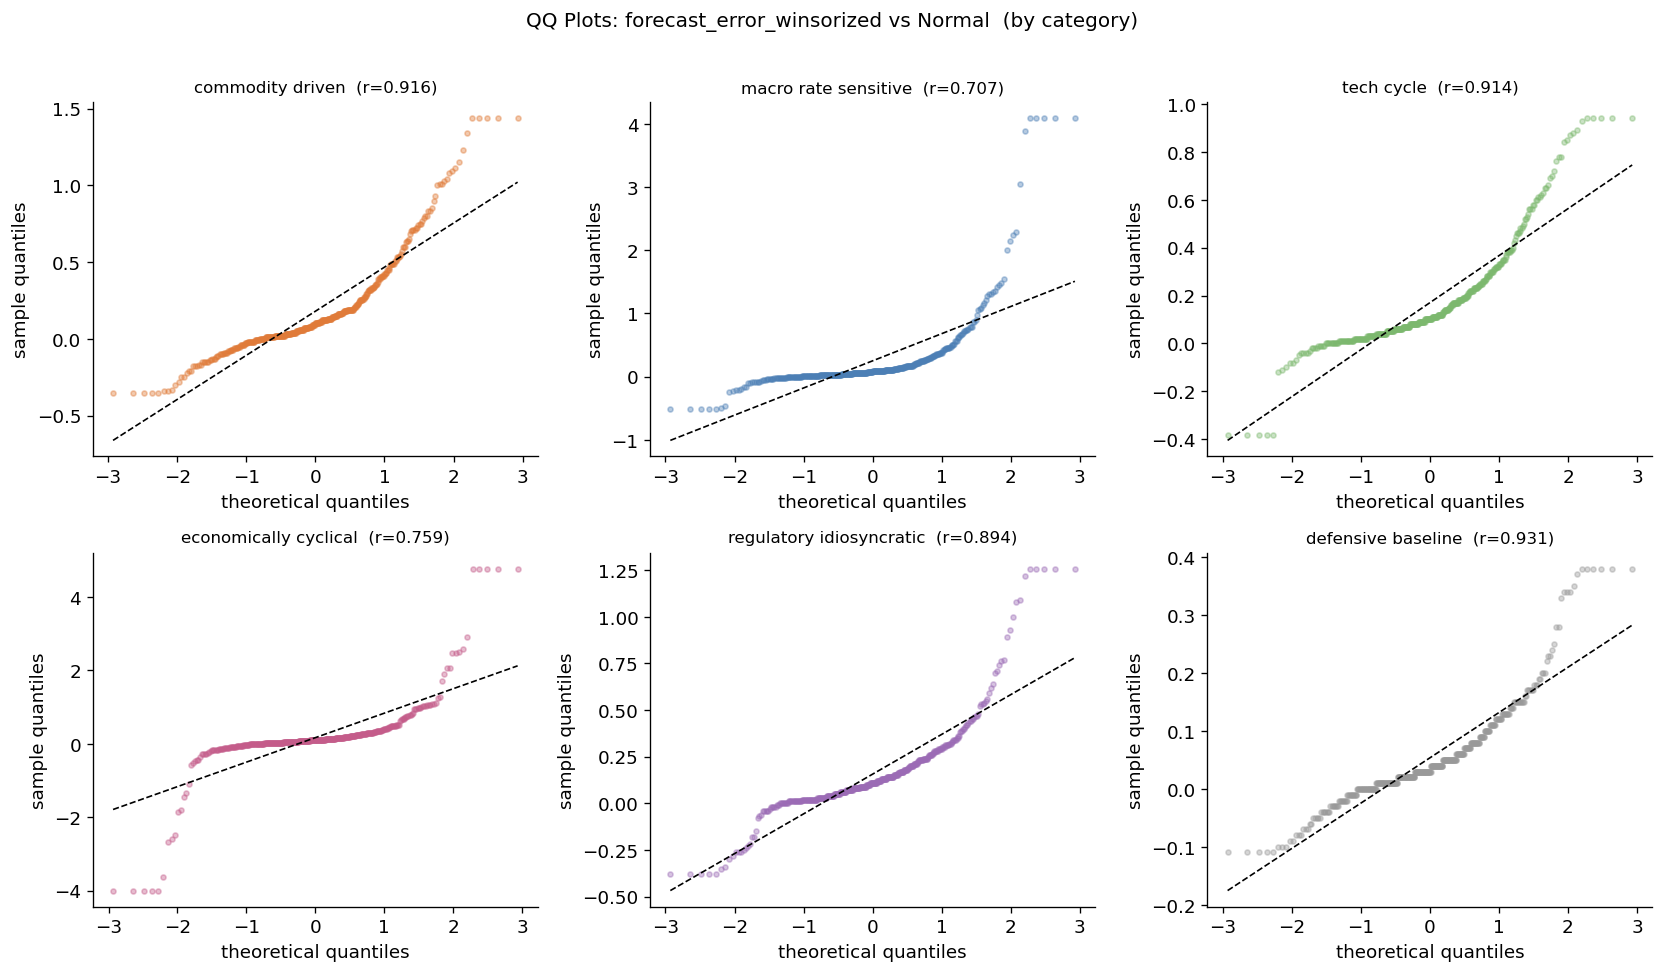

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, cat in enumerate(CATEGORY_ORDER):
    ax   = axes[i]
    data = panel[panel["category"] == cat]["forecast_error_winsorized"].dropna()

    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist="norm")
    ax.plot(osm, osr, "o", color=CAT_COLORS[cat], alpha=0.4, markersize=3)
    ax.plot(osm, slope * np.array(osm) + intercept, "k--", linewidth=1)
    ax.set_title(f"{cat.replace('_', ' ')}  (r={r:.3f})", fontsize=10)
    ax.set_xlabel("theoretical quantiles")
    ax.set_ylabel("sample quantiles")

fig.suptitle("QQ Plots: forecast_error_winsorized vs Normal  (by category)", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("../reports/figures/02_qq_plots.png", dpi=150, bbox_inches="tight")
plt.show()

## Normality assessment

QQ plots show consistent right skew and heavy right tails across all categories (r range: 0.707–0.931). The Normal likelihood assumption for the hierarchical model is violated.

**Decision:** Use Student-t likelihood in `models.py` with estimated degrees of freedom (`nu`). This is robust to the observed tail behaviour while remaining interpretable.

macro_rate_sensitive and economically_cyclical show the worst deviation — consistent with genuinely unpredictable earnings drivers (credit cycles, consumer spending shocks).

In [10]:
rng     = np.random.default_rng(42)
n_boot  = 10_000

results = []
for cat in CATEGORY_ORDER:
    vals = panel[panel["category"] == cat]["forecast_error_winsorized"].dropna().values
    boot_means = np.array([
        rng.choice(vals, size=len(vals), replace=True).mean()
        for _ in range(n_boot)
    ])
    results.append({
        "category" : cat,
        "mean"     : vals.mean(),
        "ci_lo"    : np.percentile(boot_means, 2.5),
        "ci_hi"    : np.percentile(boot_means, 97.5),
        "n"        : len(vals),
    })

boot_df = pd.DataFrame(results)
print(boot_df.to_string(index=False, float_format="{:.4f}".format))

                category   mean  ci_lo  ci_hi   n
        commodity_driven 0.1795 0.1504 0.2108 406
    macro_rate_sensitive 0.2486 0.1939 0.3104 408
              tech_cycle 0.1702 0.1499 0.1915 408
   economically_cyclical 0.1653 0.0816 0.2488 415
regulatory_idiosyncratic 0.1565 0.1337 0.1798 408
      defensive_baseline 0.0536 0.0457 0.0616 410


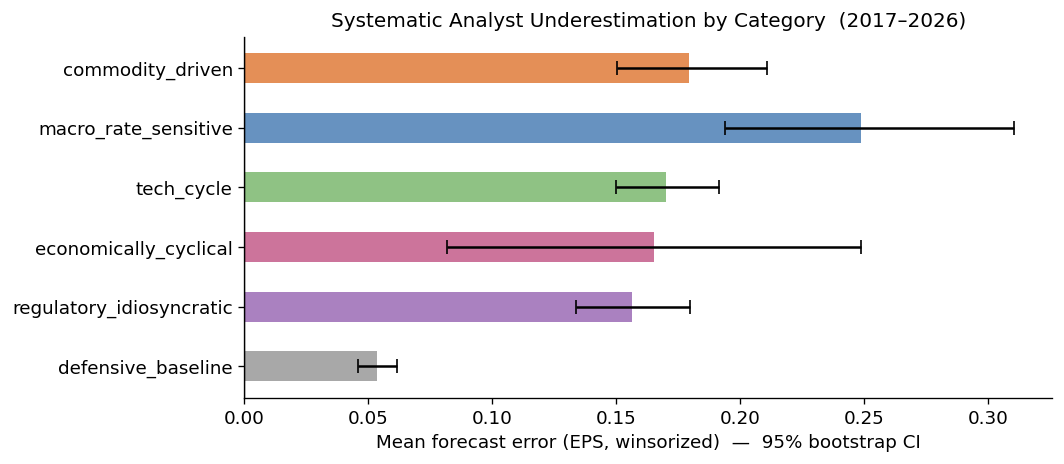

In [11]:
fig, ax = plt.subplots(figsize=(9, 4))

for i, row in boot_df.iterrows():
    cat = row["category"]
    ax.barh(cat, row["mean"], color=CAT_COLORS[cat], height=0.5, alpha=0.85)
    ax.errorbar(row["mean"], cat,
                xerr=[[row["mean"] - row["ci_lo"]], [row["ci_hi"] - row["mean"]]],
                fmt="none", color="black", capsize=4, linewidth=1.5)

ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Mean forecast error (EPS, winsorized)  —  95% bootstrap CI")
ax.set_title("Systematic Analyst Underestimation by Category  (2017–2026)", fontsize=12)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../reports/figures/02_bootstrap_bias_by_category.png", dpi=150)
plt.show()

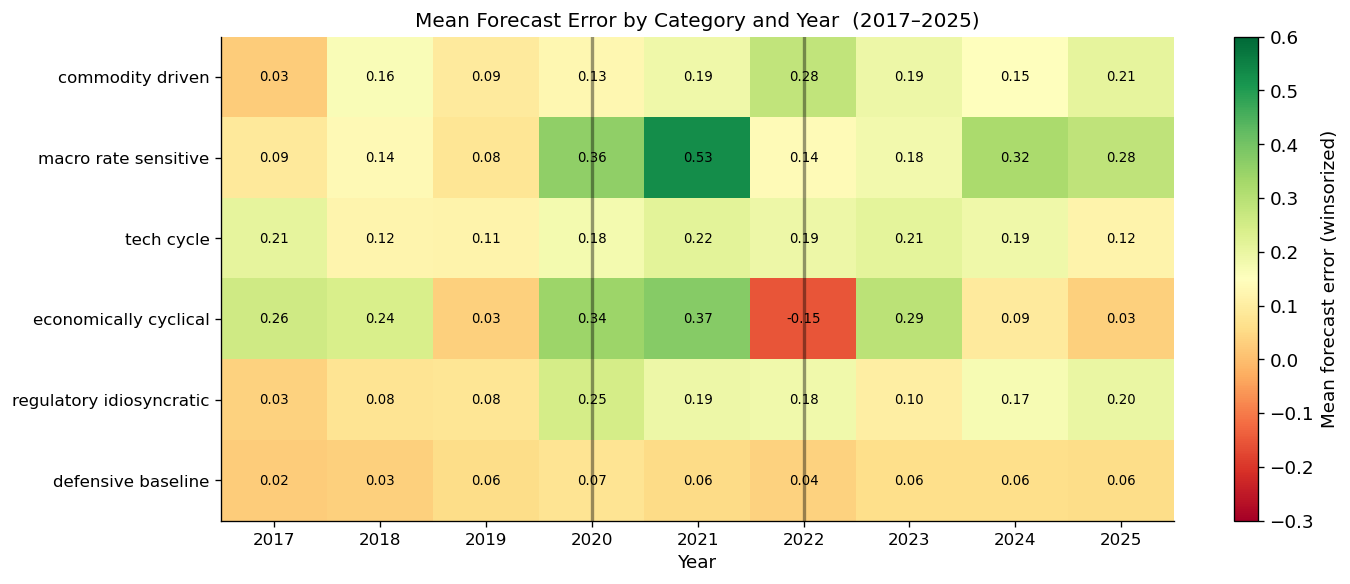

In [12]:
pivot = (
    panel.groupby(["year", "category"])["forecast_error_winsorized"]
         .mean()
         .unstack("category")
         .reindex(columns=CATEGORY_ORDER)
)
pivot = pivot[pivot.index < 2026]

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(pivot.T, aspect="auto", cmap="RdYlGn", vmin=-0.3, vmax=0.6)

ax.set_xticks(range(len(pivot.index)))
ax.set_xticklabels(pivot.index.astype(int), fontsize=10)
ax.set_yticks(range(len(CATEGORY_ORDER)))
ax.set_yticklabels([c.replace("_", " ") for c in CATEGORY_ORDER], fontsize=10)

for i, cat in enumerate(CATEGORY_ORDER):
    for j, yr in enumerate(pivot.index):
        val = pivot.loc[yr, cat]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=8, color="black")

plt.colorbar(im, ax=ax, label="Mean forecast error (winsorized)")
ax.set_title("Mean Forecast Error by Category and Year  (2017–2025)", fontsize=12)
ax.set_xlabel("Year")

for j, yr in enumerate(pivot.index):
    if yr in [2020, 2022]:
        ax.axvline(j, color="black", linewidth=2, alpha=0.4)

plt.tight_layout()
plt.savefig("../reports/figures/02_category_year_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## Category × year heatmap - key observations

- **macro_rate_sensitive** shows the strongest regime sensitivity: +0.53 in 2021 (zero-rate stimulus), compressing to +0.14 in 2022 (rate shock). Large swing driven by genuine macro unpredictability.
- **economically_cyclical 2022** is the only negative cell (−0.15) - analysts overestimated in the one year a rate shock hit consumer spending. Sign flip is the regime effect we're modelling.
- **tech_cycle** is persistently biased (~0.11–0.22) regardless of regime - structural, not cyclical.
- **defensive_baseline** is flat across all years (0.02–0.07) - confirms the control group is not picking up generic forecasting noise.

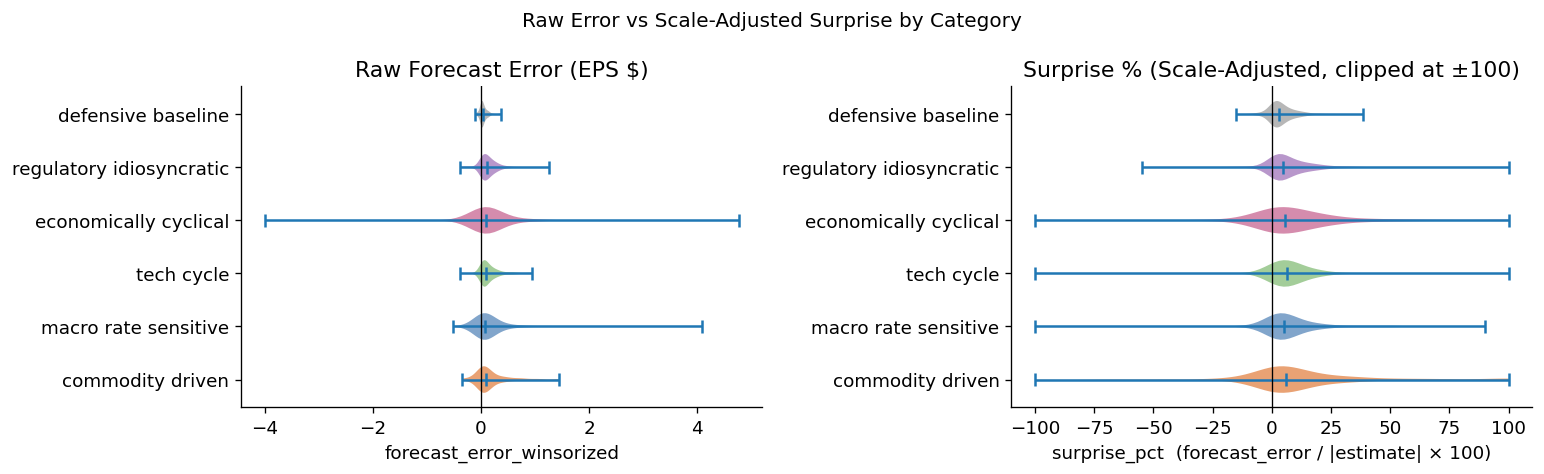

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

panel["surprise_pct_clipped"] = panel["surprise_pct"].clip(-100, 100)

data_raw = [panel[panel["category"] == cat]["forecast_error_winsorized"].dropna()
            for cat in CATEGORY_ORDER]
parts = axes[0].violinplot(data_raw, vert=False, showmedians=True)
for pc, cat in zip(parts["bodies"], CATEGORY_ORDER):
    pc.set_facecolor(CAT_COLORS[cat])
    pc.set_alpha(0.7)
axes[0].set_yticks(range(1, len(CATEGORY_ORDER) + 1))
axes[0].set_yticklabels([c.replace("_", " ") for c in CATEGORY_ORDER])
axes[0].set_xlabel("forecast_error_winsorized")
axes[0].set_title("Raw Forecast Error (EPS $)")
axes[0].axvline(0, color="black", linewidth=0.8)

data_pct = [panel[panel["category"] == cat]["surprise_pct_clipped"].dropna()
            for cat in CATEGORY_ORDER]
parts2 = axes[1].violinplot(data_pct, vert=False, showmedians=True)
for pc, cat in zip(parts2["bodies"], CATEGORY_ORDER):
    pc.set_facecolor(CAT_COLORS[cat])
    pc.set_alpha(0.7)
axes[1].set_yticks(range(1, len(CATEGORY_ORDER) + 1))
axes[1].set_yticklabels([c.replace("_", " ") for c in CATEGORY_ORDER])
axes[1].set_xlabel("surprise_pct  (forecast_error / |estimate| × 100)")
axes[1].set_title("Surprise % (Scale-Adjusted, clipped at ±100)")
axes[1].axvline(0, color="black", linewidth=0.8)

fig.suptitle("Raw Error vs Scale-Adjusted Surprise by Category", fontsize=12)
plt.tight_layout()
plt.savefig("../reports/figures/02_surprise_pct_vs_raw.png", dpi=150)
plt.show()

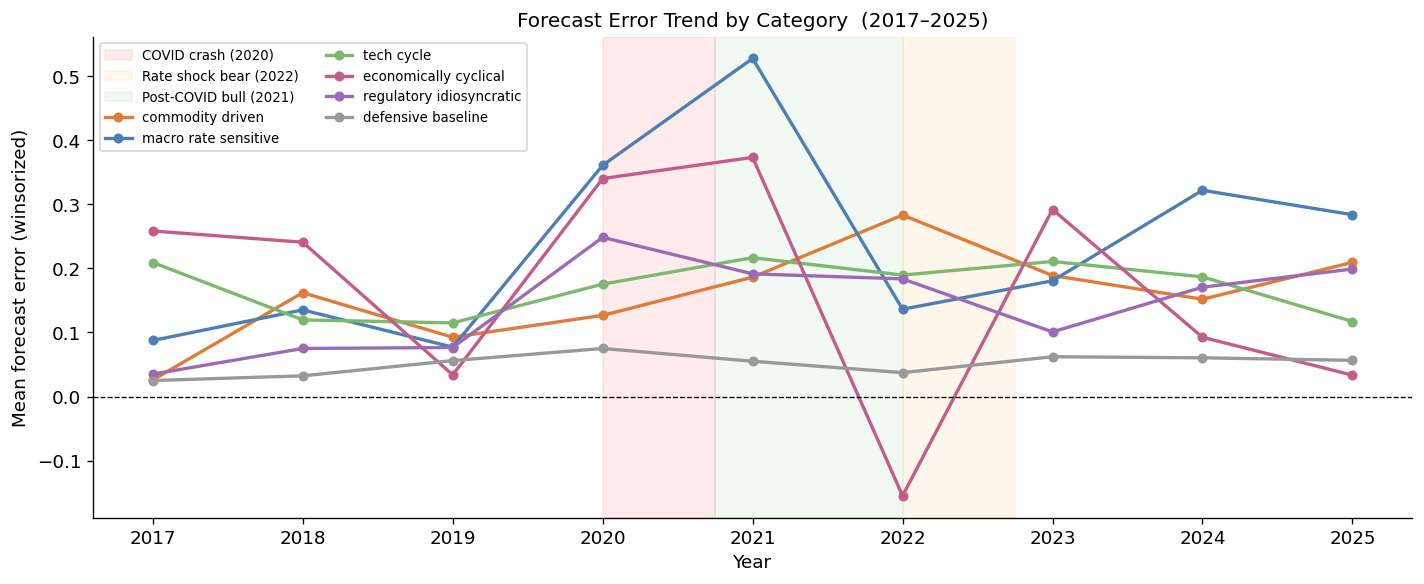

In [14]:
yearly = (
    panel[panel["year"] < 2026]
    .groupby(["year", "category"])["forecast_error_winsorized"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))

# Shade known regime periods
ax.axvspan(2020, 2020.75, color="red",  alpha=0.08, label="COVID crash (2020)")
ax.axvspan(2022, 2022.75, color="orange", alpha=0.08, label="Rate shock bear (2022)")
ax.axvspan(2020.75, 2022, color="green", alpha=0.05, label="Post-COVID bull (2021)")

for cat in CATEGORY_ORDER:
    data = yearly[yearly["category"] == cat]
    ax.plot(data["year"], data["forecast_error_winsorized"],
            marker="o", linewidth=2, markersize=5,
            color=CAT_COLORS[cat], label=cat.replace("_", " "))

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Year")
ax.set_ylabel("Mean forecast error (winsorized)")
ax.set_title("Forecast Error Trend by Category  (2017–2025)", fontsize=12)
ax.set_xticks(range(2017, 2026))
ax.legend(fontsize=8, ncol=2, loc="upper left")
plt.tight_layout()
plt.savefig("../reports/figures/02_yearly_trend_by_category.png", dpi=150)
plt.show()

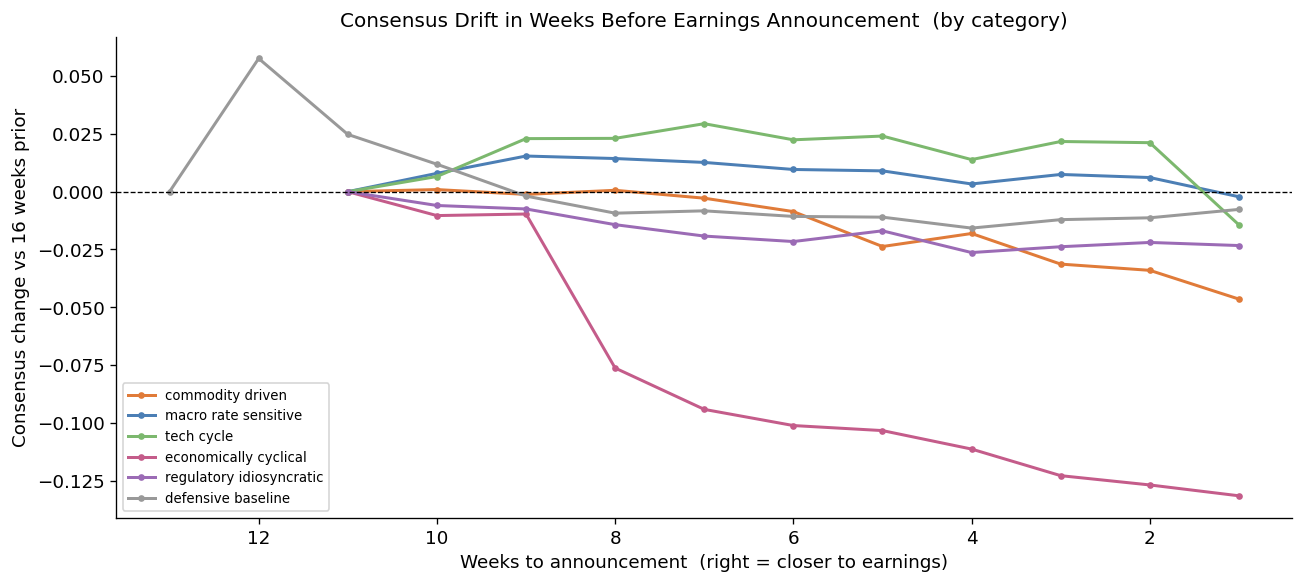

In [15]:
est = estimate[estimate["period"] == "Current Quarter"].copy()

announcement_dates = panel[["act_symbol", "period_end_date"]].drop_duplicates()
est = est.merge(announcement_dates, on=["act_symbol", "period_end_date"], how="inner")

est["weeks_to_ann"] = (
    (est["period_end_date"] - est["date"]).dt.days / 7
).round().astype(int)
est = est[(est["weeks_to_ann"] >= 1) & (est["weeks_to_ann"] <= 16)]

def normalize_consensus(group):
    base = group[group["weeks_to_ann"] == group["weeks_to_ann"].max()]["consensus"].mean()
    group["consensus_normalized"] = group["consensus"] - base
    return group

est = est.groupby(["act_symbol", "period_end_date"], group_keys=False).apply(normalize_consensus)

drift = (
    est.groupby(["category", "weeks_to_ann"])["consensus_normalized"]
       .mean()
       .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5))
for cat in CATEGORY_ORDER:
    data = drift[drift["category"] == cat].sort_values("weeks_to_ann", ascending=False)
    ax.plot(data["weeks_to_ann"], data["consensus_normalized"],
            marker="o", markersize=3, linewidth=1.8,
            color=CAT_COLORS[cat], label=cat.replace("_", " "))

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.invert_xaxis()
ax.set_xlabel("Weeks to announcement  (right = closer to earnings)")
ax.set_ylabel("Consensus change vs 16 weeks prior")
ax.set_title("Consensus Drift in Weeks Before Earnings Announcement  (by category)", fontsize=12)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("../reports/figures/02_consensus_drift.png", dpi=150)
plt.show()

## Consensus drift - key observations

- **economically_cyclical** shows the sharpest downward revision path; analysts cut estimates by 0.13 EPS on average in the 8 weeks before announcement. Late-arriving bad news.
- **tech_cycle** drifts upward but still undershoots — analysts chase the number but don't catch it, consistent with 90.7% beat rate.
- **macro_rate_sensitive** barely revises — persistent bias set early, not corrected.
- **defensive_baseline** is flat near zero as expected — control group holds.

Note: spike in defensive_baseline at 12-13 weeks is likely thin-sample noise at long horizons.

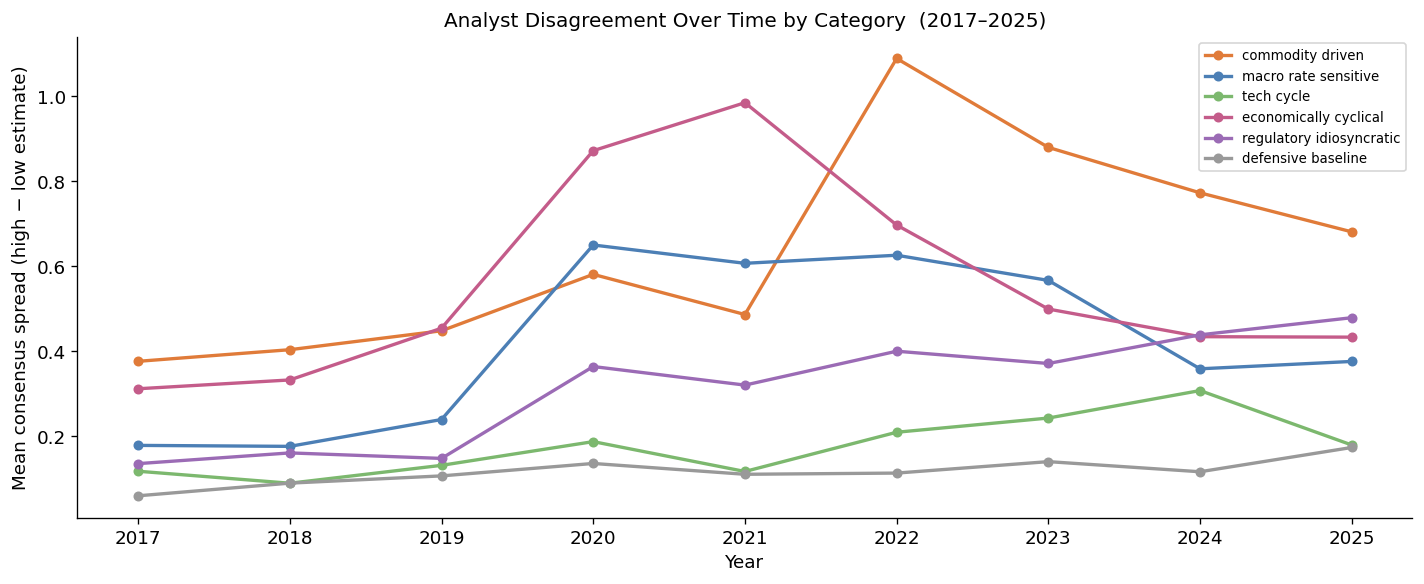

In [16]:
spread_yearly = (
    estimate[estimate["period"] == "Current Quarter"]
    .groupby(["year", "category"])["consensus_spread"]
    .mean()
    .reset_index()
)
spread_yearly = spread_yearly[spread_yearly["year"] < 2026]

fig, ax = plt.subplots(figsize=(12, 5))
for cat in CATEGORY_ORDER:
    data = spread_yearly[spread_yearly["category"] == cat]
    ax.plot(data["year"], data["consensus_spread"],
            marker="o", linewidth=2, markersize=5,
            color=CAT_COLORS[cat], label=cat.replace("_", " "))

ax.set_xlabel("Year")
ax.set_ylabel("Mean consensus spread (high − low estimate)")
ax.set_title("Analyst Disagreement Over Time by Category  (2017–2025)", fontsize=12)
ax.set_xticks(range(2017, 2026))
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("../reports/figures/02_consensus_spread.png", dpi=150)
plt.show()

## Consensus spread - herding signal

High spread = disagreement. Low spread = potential herding (analysts converging on a shared estimate).

- **tech_cycle** has the lowest spread but the highest beat rate (90.7%) - analysts agree with each other but are collectively wrong. Classic herding signature.
- **commodity_driven 2022**: spread of 1.10 — genuine uncertainty, not herding.
- **defensive_baseline**: low spread, low bias — analysts agree and are right.

This distinction (coordinated error vs genuine disagreement) motivates the herding coefficient in `models.py`.